# Weather Condition Classification using SVM and Open-Meteo API

**Name:** Aditya Shukla

**Registration Number:** 23BAI10155

**Application Number:** IN26011099

**Batch Number:** 1(A)

**Email ID:** aditya.23bai10155@vitbhopal.ac.in


In [5]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [6]:
url='https://api.open-meteo.com/v1/forecast'
params={'latitude':12.9716,'longitude':77.5946,'hourly':'temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m','forecast_days':7}
response=requests.get(url,params=params)
response.raise_for_status()
df=pd.DataFrame(response.json()['hourly'])
df.head()

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2026-07-28T00:00,21.4,89,908.1,14.1
1,2026-07-28T01:00,21.2,90,908.5,14.0
2,2026-07-28T02:00,22.2,84,909.3,14.7
3,2026-07-28T03:00,23.7,75,910.1,19.7
4,2026-07-28T04:00,25.0,68,910.6,21.0


In [7]:
input_features=['temperature_2m','relative_humidity_2m','surface_pressure','wind_speed_10m']
df=df.drop(columns=['time'])
df['Weather_Class']=np.where(df['temperature_2m']>=25,'Warm','Cool')
le=LabelEncoder()
y=le.fit_transform(df['Weather_Class'])
X=df[input_features].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Accuracy: 0.9117647058823529
Precision: 0.930672268907563
Recall: 0.9117647058823529
F1: 0.9139808481532148


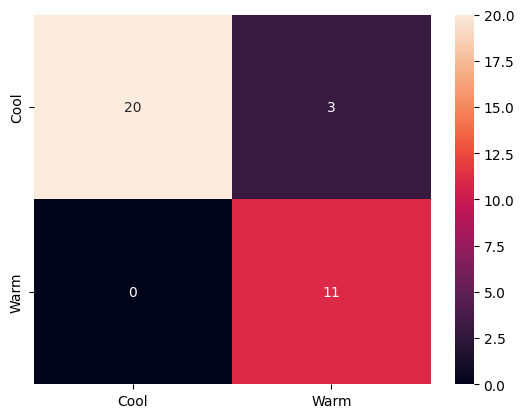

In [8]:
model=SVC(kernel='rbf',random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred,average='weighted'))
print('Recall:',recall_score(y_test,y_pred,average='weighted'))
print('F1:',f1_score(y_test,y_pred,average='weighted'))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=le.classes_,yticklabels=le.classes_)
plt.show()

## Conclusion

This project used live weather data from the Open-Meteo API to develop an SVM classifier with an RBF kernel for classifying weather conditions as Warm or Cool using temperature, relative humidity, surface pressure, and wind speed. The weather data was collected for Bengaluru, providing sufficient variation in temperature to generate both target classes. The model achieved high classification accuracy because the target variable was created directly from the temperature threshold (≥ 25°C), which is also one of the input features. Feature scaling using StandardScaler played a crucial role in improving the SVM's performance by ensuring that features with larger numerical ranges, such as surface pressure, did not dominate those with smaller ranges, such as wind speed. One major advantage of the SVM algorithm is its ability to model non-linear decision boundaries effectively through the RBF kernel. However, a limitation of SVM is that it becomes computationally expensive for very large datasets and is less interpretable than simpler models such as Decision Trees.